In [ ]:
#@title Instalación
!pip install dandi
!dandi download https://gui.dandiarchive.org/#/dandiset/000128
!pip install git+https://github.com/neurallatents/nlb_tools.git


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.0/395.0 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 MB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.6/118.6 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.9/86.9 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 65.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.4/96.4 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 20.9 MB/s eta 0:00:00
  Attempting uninstall: click
    Found existin

In [ ]:
!pip install pynwb h5py

In [ ]:
#@title Path and structure
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import skew, kurtosis
from scipy.ndimage import gaussian_filter1d
import os, shutil
import glob

for root, dirs, files in os.walk('/content'):
    for f in files:
        if f.endswith('.nwb'):
            print(os.path.join(root, f))

# Encuentra el archivo
archivos = glob.glob('/content/000128/**/*.nwb', recursive=True)
print(archivos)

os.makedirs('/content/eda_outputs', exist_ok=True)

# Cargar archivo de entrenamiento
fpath = '/content/000128/sub-Jenkins/sub-Jenkins_ses-full_desc-train_behavior+ecephys.nwb'
f = h5py.File(fpath, 'r')


# Ver estructura
def print_structure(name, obj):
    print(name)

f.visititems(print_structure)

os.makedirs('/content/eda_outputs', exist_ok=True)
fpath = '/content/000128/sub-Jenkins/sub-Jenkins_ses-full_desc-train_behavior+ecephys.nwb'
f = h5py.File(fpath, 'r')

/content/000128/sub-Jenkins/sub-Jenkins_ses-full_desc-train_behavior+ecephys.nwb
/content/000128/sub-Jenkins/sub-Jenkins_ses-full_desc-test_ecephys.nwb
['/content/000128/sub-Jenkins/sub-Jenkins_ses-full_desc-train_behavior+ecephys.nwb', '/content/000128/sub-Jenkins/sub-Jenkins_ses-full_desc-test_ecephys.nwb']
acquisition
analysis
file_create_date
general
general/devices
general/devices/electrode_array_M1
general/devices/electrode_array_PMd
general/experiment_description
general/experimenter
general/extracellular_ephys
general/extracellular_ephys/electrode_group_M1
general/extracellular_ephys/electrode_group_PMd
general/extracellular_ephys/electrodes
general/extracellular_ephys/electrodes/filtering
general/extracellular_ephys/electrodes/group
general/extracellular_ephys/electrodes/group_name
general/extracellular_ephys/electrodes/id
general/extracellular_ephys/electrodes/imp
general/extracellular_ephys/electrodes/location
general/extracellular_ephys/electrodes/x
general/extracellular_ep

# Programa principal

In [ ]:
#@title Estadísticas generales
trial_type    = f['intervals/trials/trial_type'][:]
trial_version = f['intervals/trials/trial_version'][:]
start_times   = f['intervals/trials/start_time'][:]
stop_times    = f['intervals/trials/stop_time'][:]
go_cue        = f['intervals/trials/go_cue_time'][:]
move_onset    = f['intervals/trials/move_onset_time'][:]
target_on     = f['intervals/trials/target_on_time'][:]
success       = f['intervals/trials/success'][:]
n_trials      = len(trial_type)

spike_times_flat  = f['units/spike_times'][:]
spike_times_index = f['units/spike_times_index'][:]
n_neurons         = len(spike_times_index)

conds = list(set(zip(trial_type, trial_version)))
n_conds = len(conds)

print("=" * 50)
print("ESTADÍSTICAS GENERALES")
print("=" * 50)
print(f"Trials totales        : {n_trials}")
print(f"Condiciones (clases)  : {n_conds}")
print(f"Neuronas              : {n_neurons}")
print(f"Duración media trial  : {np.mean(stop_times - start_times)*1000:.1f} ms")
print(f"Delay medio (target→go): {np.mean((go_cue - target_on)*1000):.1f} ms")
print(f"RT medio              : {np.mean((move_onset - go_cue)*1000):.1f} ms")

pd.DataFrame({
    'Métrica': ['Trials totales','Condiciones','Neuronas',
                'Duración media trial (ms)','Delay medio (ms)','RT medio (ms)'],
    'Valor': [n_trials, n_conds, n_neurons,
              round(np.mean(stop_times-start_times)*1000,1),
              round(np.mean((go_cue-target_on)*1000),1),
              round(np.mean((move_onset-go_cue)*1000),1)]
}).to_csv('/content/eda_outputs/stats_generales.csv', index=False)


ESTADÍSTICAS GENERALES
Trials totales        : 2295
Condiciones (clases)  : 108
Neuronas              : 182
Duración media trial  : 2967.3 ms
Delay medio (target→go): 645.3 ms
RT medio              : 349.3 ms



Trials por condición — media: 21.2 | min: 17 | max: 27 | std: 2.09


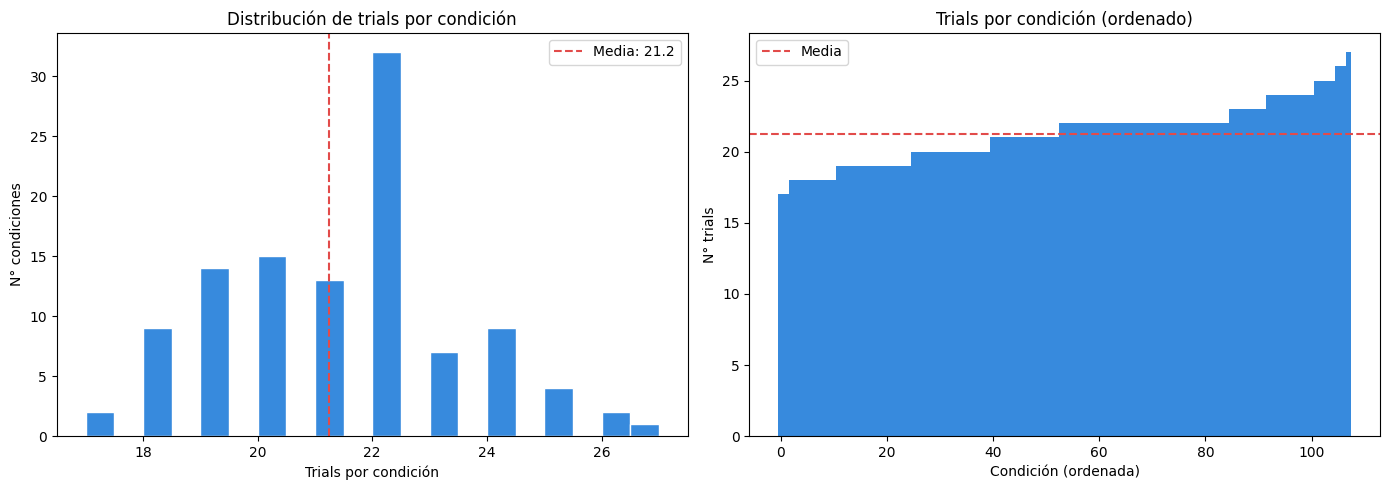

fig1 guardado


In [ ]:
#@title Distribución de Clases
trials_df = pd.DataFrame({'trial_type': trial_type, 'trial_version': trial_version})
counts = trials_df.groupby(['trial_type','trial_version']).size().reset_index(name='n')

print(f"\nTrials por condición — media: {counts.n.mean():.1f} | "
      f"min: {counts.n.min()} | max: {counts.n.max()} | std: {counts.n.std():.2f}")
counts.to_csv('/content/eda_outputs/trials_por_condicion.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(counts.n, bins=20, color='#378ADD', edgecolor='white')
axes[0].axvline(counts.n.mean(), color='#E24B4A', linestyle='--',
                label=f"Media: {counts.n.mean():.1f}")
axes[0].set_xlabel('Trials por condición'); axes[0].set_ylabel('N° condiciones')
axes[0].set_title('Distribución de trials por condición'); axes[0].legend()

axes[1].bar(range(len(counts)), sorted(counts.n), color='#378ADD', width=1.0)
axes[1].axhline(counts.n.mean(), color='#E24B4A', linestyle='--', label='Media')
axes[1].set_xlabel('Condición (ordenada)'); axes[1].set_ylabel('N° trials')
axes[1].set_title('Trials por condición (ordenado)'); axes[1].legend()

plt.tight_layout()
plt.savefig('/content/eda_outputs/fig1_distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()
print("fig1 guardado")

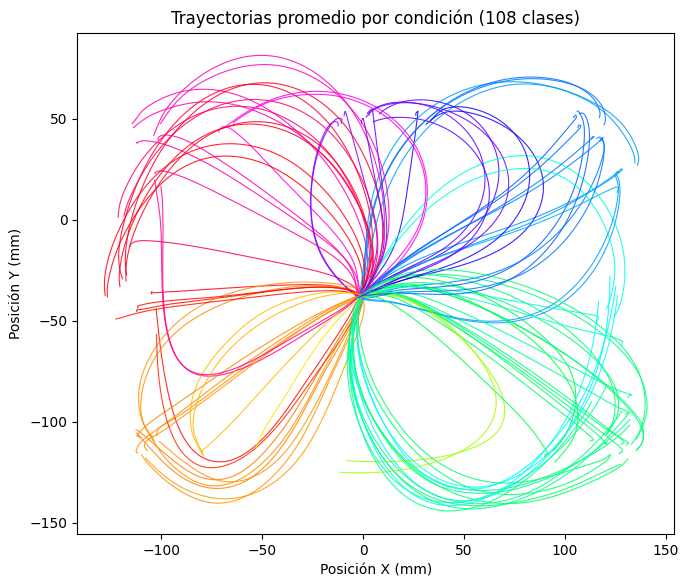

fig2 guardado


In [ ]:
#@title Trayectorias de la mano
hand_pos_data = f['processing/behavior/hand_pos/data'][:]
hand_pos_ts   = f['processing/behavior/hand_pos/timestamps'][:]
BIN = 0.005  # 5 ms

def get_trial_signal(data, timestamps, t_start, t_end):
    mask = (timestamps >= t_start) & (timestamps < t_end)
    return data[mask], timestamps[mask]

fig, ax = plt.subplots(figsize=(7, 7))
for tt, tv in conds:
    mask = (trial_type == tt) & (trial_version == tv)
    idx  = np.where(mask)[0]
    trajs = []
    for i in idx:
        seg, _ = get_trial_signal(hand_pos_data, hand_pos_ts,
                                  move_onset[i] - 0.05, move_onset[i] + 0.45)
        if len(seg) > 5:
            trajs.append(seg)
    if trajs:
        min_len = min(len(t) for t in trajs)
        avg = np.mean([t[:min_len] for t in trajs], axis=0)
        angle = np.arctan2(avg[-1, 1] - avg[0, 1], avg[-1, 0] - avg[0, 0])
        color = cm.hsv((angle + np.pi) / (2 * np.pi))
        ax.plot(avg[:, 0], avg[:, 1], linewidth=0.8, color=color, alpha=0.85)

ax.set_xlabel('Posición X (mm)'); ax.set_ylabel('Posición Y (mm)')
ax.set_title('Trayectorias promedio por condición (108 clases)')
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('/content/eda_outputs/fig2_trayectorias.png', dpi=150, bbox_inches='tight')
plt.show()
print("fig2 guardado")


Firing rates (Hz) — media: 2.88 | mediana: 1.68 | min: 0.12 | max: 15.46 | std: 3.32 | skew: 1.889 | kurtosis: 3.139


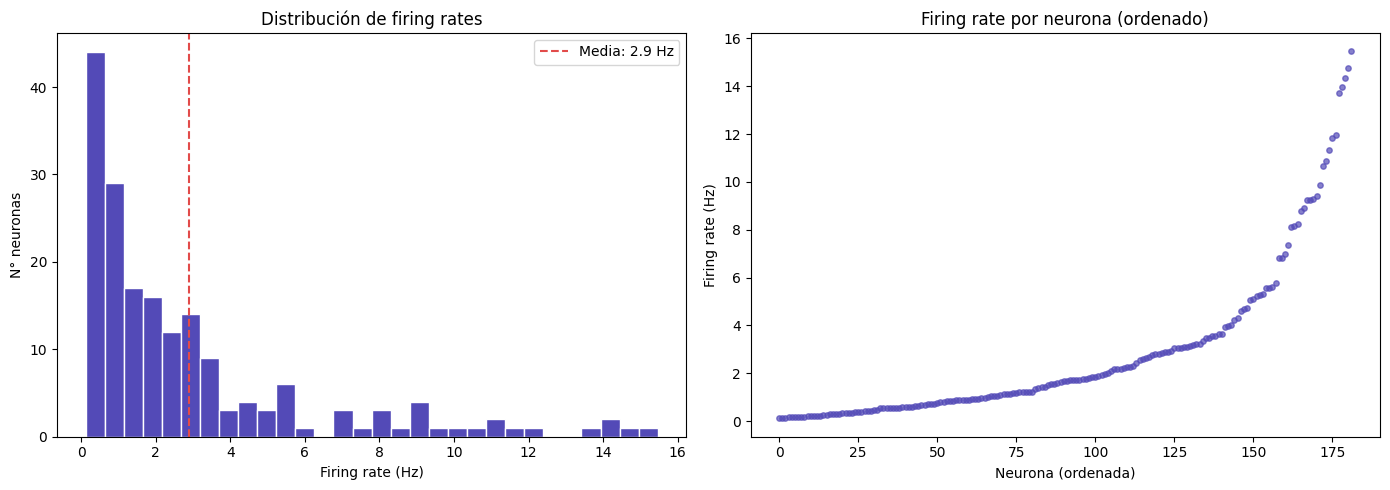

fig3 guardado


In [ ]:
#@title Firing Rates
def get_spike_times_neuron(n):
    start = spike_times_index[n-1] if n > 0 else 0
    end   = spike_times_index[n]
    return spike_times_flat[int(start):int(end)]

# Firing rate promedio por neurona (sobre toda la sesión)
session_dur = float(stop_times[-1] - start_times[0])
mean_fr = []
for n in range(n_neurons):
    spk = get_spike_times_neuron(n)
    mean_fr.append(len(spk) / session_dur)
mean_fr = np.array(mean_fr)

print(f"\nFiring rates (Hz) — media: {mean_fr.mean():.2f} | "
      f"mediana: {np.median(mean_fr):.2f} | min: {mean_fr.min():.2f} | "
      f"max: {mean_fr.max():.2f} | std: {mean_fr.std():.2f} | "
      f"skew: {skew(mean_fr):.3f} | kurtosis: {kurtosis(mean_fr):.3f}")

pd.DataFrame({'neurona': range(n_neurons), 'mean_fr_hz': mean_fr})\
  .to_csv('/content/eda_outputs/stats_firing_rates.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(mean_fr, bins=30, color='#534AB7', edgecolor='white')
axes[0].axvline(mean_fr.mean(), color='#E24B4A', linestyle='--',
                label=f"Media: {mean_fr.mean():.1f} Hz")
axes[0].set_xlabel('Firing rate (Hz)'); axes[0].set_ylabel('N° neuronas')
axes[0].set_title('Distribución de firing rates'); axes[0].legend()

axes[1].scatter(range(n_neurons), sorted(mean_fr), s=15, color='#534AB7', alpha=0.7)
axes[1].set_xlabel('Neurona (ordenada)'); axes[1].set_ylabel('Firing rate (Hz)')
axes[1].set_title('Firing rate por neurona (ordenado)')
plt.tight_layout()
plt.savefig('/content/eda_outputs/fig3_firing_rates.png', dpi=150, bbox_inches='tight')
plt.show()
print("fig3 guardado")

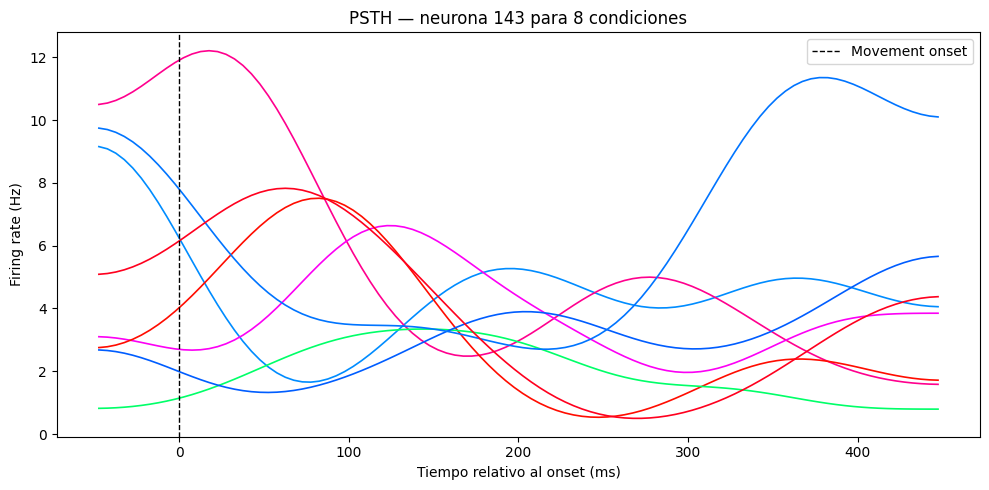

fig4 guardado


In [ ]:
#@title PSTH — NEURONA INDIVIDUAL
def compute_psth(neuron_idx, trial_mask, align_times, window=(-0.05, 0.45), sigma_ms=50):
    bin_edges = np.arange(window[0], window[1] + BIN, BIN)
    counts    = np.zeros(len(bin_edges) - 1)
    spk       = get_spike_times_neuron(neuron_idx)
    n_tr      = 0
    for i in np.where(trial_mask)[0]:
        t0   = align_times[i]
        rel  = spk - t0
        h, _ = np.histogram(rel, bins=bin_edges)
        counts += h
        n_tr  += 1
    if n_tr == 0:
        return np.zeros(len(bin_edges)-1), bin_edges
    rate = counts / n_tr / BIN  # Hz
    sigma_bins = sigma_ms / 1000 / BIN
    rate = gaussian_filter1d(rate, sigma=sigma_bins)
    return rate, bin_edges

np.random.seed(2468)
neur_idx   = np.random.randint(0, n_neurons)
conds_plot = [conds[i] for i in np.random.choice(len(conds), 8, replace=False)]
t_centers  = np.arange(-0.05 + BIN/2, 0.45, BIN) * 1000

fig, ax = plt.subplots(figsize=(10, 5))
for tt, tv in conds_plot:
    mask  = (trial_type == tt) & (trial_version == tv)
    rate, _ = compute_psth(neur_idx, mask, move_onset)
    idx_ex  = np.where(mask)[0][0]
    # color por dirección
    seg, _  = get_trial_signal(hand_pos_data, hand_pos_ts,
                               move_onset[idx_ex], move_onset[idx_ex]+0.45)
    if len(seg) > 1:
        angle = np.arctan2(seg[-1,1]-seg[0,1], seg[-1,0]-seg[0,0])
    else:
        angle = 0
    color = cm.hsv((angle + np.pi) / (2 * np.pi))
    ax.plot(t_centers[:len(rate)], rate, linewidth=1.2, color=color)

ax.axvline(0, color='black', linestyle='--', linewidth=1, label='Movement onset')
ax.set_xlabel('Tiempo relativo al onset (ms)'); ax.set_ylabel('Firing rate (Hz)')
ax.set_title(f'PSTH — neurona {neur_idx} para 8 condiciones')
ax.legend()
plt.tight_layout()
plt.savefig('/content/eda_outputs/fig4_psth.png', dpi=150, bbox_inches='tight')
plt.show()
print("fig4 guardado")


Componentes para 90% varianza: 46
Varianza acumulada (3 PCs): 30.4%
Varianza acumulada (10 PCs): 57.0%
Varianza acumulada (46 PCs): 90.0%


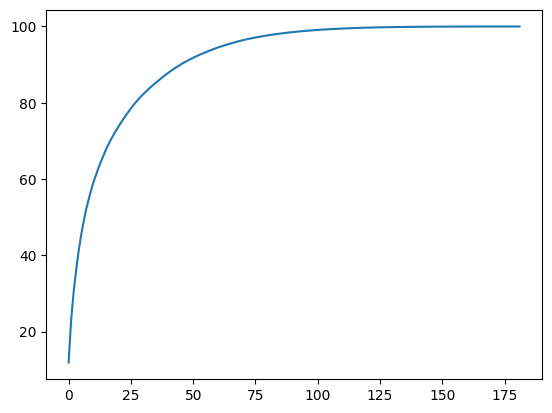

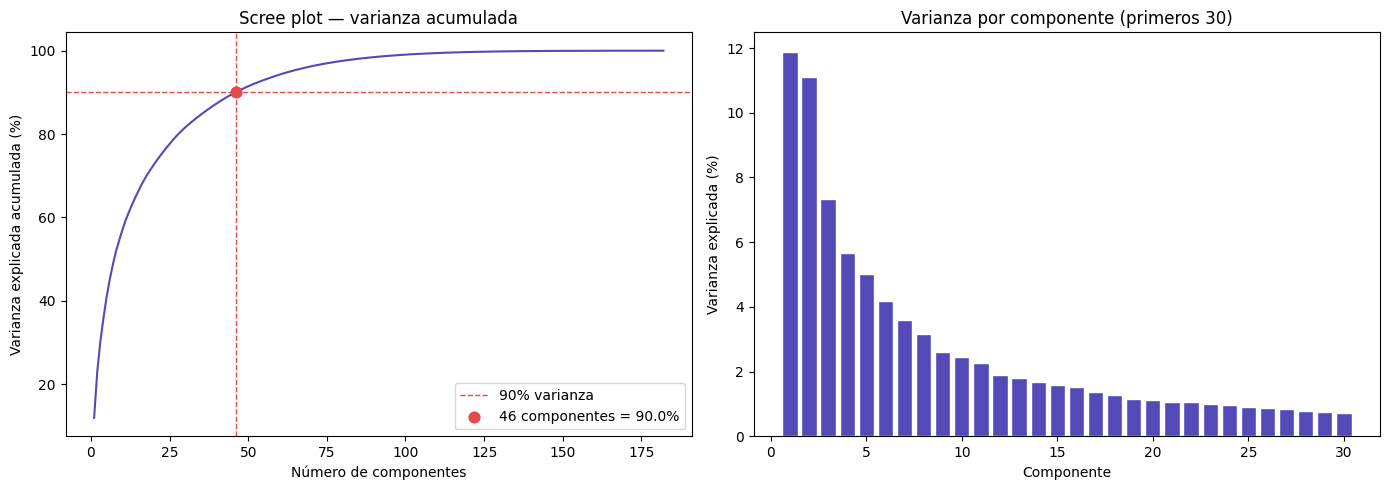

fig5_scree guardado


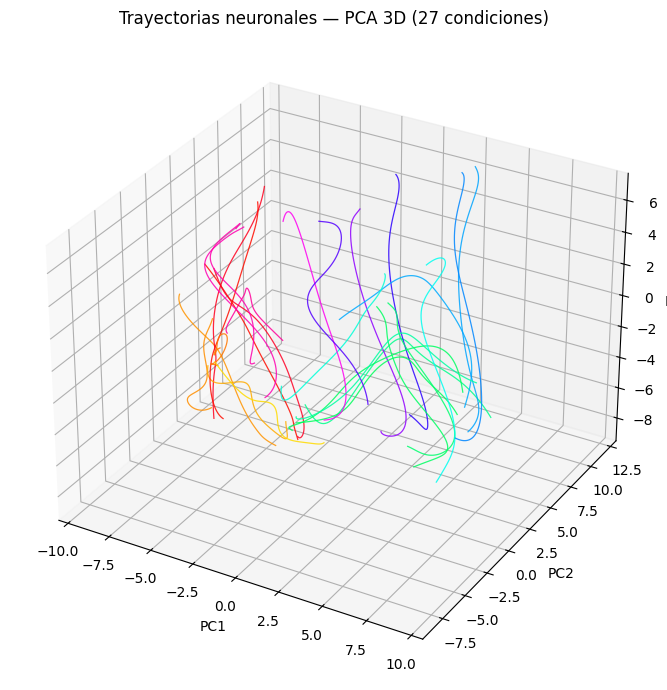

fig5_pca guardado


In [ ]:
#@title PCA DE TRAYECTORIAS NEURONALES
np.random.seed(2021)
n_bins  = int(0.5 / BIN)  # 100 bins
conds_pca = [conds[i] for i in np.random.choice(len(conds), 27, replace=False)]

rates_list, colors_list = [], []
for tt, tv in conds_pca:
    mask = (trial_type == tt) & (trial_version == tv)
    pop  = []
    for i in np.where(mask)[0]:
        t0  = move_onset[i] - 0.05
        row = []
        for n in range(n_neurons):
            spk = get_spike_times_neuron(n)
            rel = spk - move_onset[i]
            h, _ = np.histogram(rel, bins=np.arange(-0.05, 0.45+BIN, BIN))
            row.append(h)
        pop.append(np.array(row).T)  # (100, n_neurons)
    if pop:
        avg = np.mean(pop, axis=0)
        # suavizar
        avg = np.array([gaussian_filter1d(avg[:,n], sigma=10) for n in range(n_neurons)]).T
        rates_list.append(avg)
        seg, _ = get_trial_signal(hand_pos_data, hand_pos_ts,
                                  move_onset[np.where(mask)[0][0]],
                                  move_onset[np.where(mask)[0][0]]+0.45)
        if len(seg) > 1:
            angle = np.arctan2(seg[-1,1]-seg[0,1], seg[-1,0]-seg[0,0])
        else:
            angle = 0
        colors_list.append(cm.hsv((angle + np.pi) / (2 * np.pi)))

all_rates  = np.vstack(rates_list)
scaler     = StandardScaler()
scaled     = scaler.fit_transform(all_rates)
pca        = PCA(n_components=182)
pca_result = pca.fit(scaled)
cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
plt.plot(cumvar)

pca_full = PCA(n_components=min(182, scaled.shape[0]))
pca_full.fit(scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100

# Número de componentes para 90% de varianza
n_90 = np.argmax(cumvar >= 90) + 1
print(f"\nComponentes para 90% varianza: {n_90}")
print(f"Varianza acumulada (3 PCs): {cumvar[2]:.1f}%")
print(f"Varianza acumulada (10 PCs): {cumvar[9]:.1f}%")
print(f"Varianza acumulada ({n_90} PCs): {cumvar[n_90-1]:.1f}%")

# Guardar stats PCA completo
pd.DataFrame({
    'PC': range(1, len(cumvar)+1),
    'var_%': pca_full.explained_variance_ratio_*100,
    'var_acumulada_%': cumvar
}).to_csv('/content/eda_outputs/stats_pca.csv', index=False)

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, len(cumvar)+1), cumvar, color='#534AB7', linewidth=1.5)
axes[0].axhline(90, color='#E24B4A', linestyle='--', linewidth=1, label='90% varianza')
axes[0].axvline(n_90, color='#E24B4A', linestyle='--', linewidth=1)
axes[0].scatter([n_90], [cumvar[n_90-1]], color='#E24B4A', s=60, zorder=5,
                label=f'{n_90} componentes = {cumvar[n_90-1]:.1f}%')
axes[0].set_xlabel('Número de componentes'); axes[0].set_ylabel('Varianza explicada acumulada (%)')
axes[0].set_title('Scree plot — varianza acumulada'); axes[0].legend()

n_show = min(30, len(pca_full.explained_variance_ratio_))
axes[1].bar(range(1, n_show + 1),
            pca_full.explained_variance_ratio_[:n_show] * 100,
            color='#534AB7', edgecolor='white')
axes[1].set_xlabel('Componente'); axes[1].set_ylabel('Varianza explicada (%)')
axes[1].set_title('Varianza por componente (primeros 30)')

plt.tight_layout()
plt.savefig('/content/eda_outputs/fig5_scree.png', dpi=150, bbox_inches='tight')
plt.show()
print("fig5_scree guardado")

# PCA 3D para visualización (igual que antes)
pca = PCA(n_components=3)
pca_result = pca.fit_transform(scaled)

from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(9, 7))
ax  = fig.add_subplot(111, projection='3d')
idx = 0
n_t = rates_list[0].shape[0]
for i, _ in enumerate(rates_list):
    traj = pca_result[idx:idx+n_t]
    ax.plot(traj[:,0], traj[:,1], traj[:,2], linewidth=0.9, color=colors_list[i], alpha=0.85)
    idx += n_t
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
ax.set_title('Trayectorias neuronales — PCA 3D (27 condiciones)')
plt.tight_layout()
plt.savefig('/content/eda_outputs/fig5_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print("fig5_pca guardado")


Velocidad mano (mm/s) — media: 67.9 | mediana: 5.2 | max: 1359.9 | std: 177.1


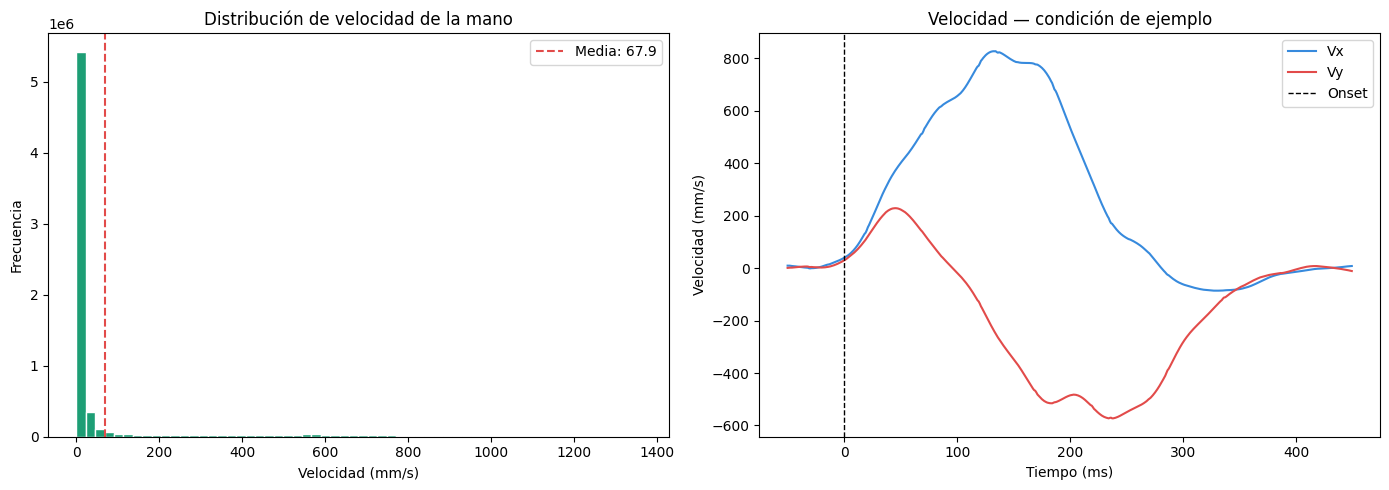

fig6 guardado


In [ ]:
#@title VELOCIDAD DE LA MANO
hand_vel_data = f['processing/behavior/hand_vel/data'][:]
hand_vel_ts   = f['processing/behavior/hand_vel/timestamps'][:]
vel_mag       = np.sqrt(hand_vel_data[:,0]**2 + hand_vel_data[:,1]**2)

print(f"\nVelocidad mano (mm/s) — media: {vel_mag.mean():.1f} | "
      f"mediana: {np.median(vel_mag):.1f} | max: {vel_mag.max():.1f} | "
      f"std: {vel_mag.std():.1f}")

pd.DataFrame({'Métrica':['Media','Mediana','Máx','Std'],
              'mm_s':[vel_mag.mean(), np.median(vel_mag),
                      vel_mag.max(), vel_mag.std()]})\
  .to_csv('/content/eda_outputs/stats_velocidad.csv', index=False)

tt0, tv0 = conds[0]
mask0 = (trial_type == tt0) & (trial_version == tv0)
i0    = np.where(mask0)[0][0]
seg_v, ts_v = get_trial_signal(hand_vel_data, hand_vel_ts,
                               move_onset[i0]-0.05, move_onset[i0]+0.45)
t_ms = (ts_v - move_onset[i0]) * 1000

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(vel_mag, bins=60, color='#1D9E75', edgecolor='white')
axes[0].axvline(vel_mag.mean(), color='#E24B4A', linestyle='--',
                label=f"Media: {vel_mag.mean():.1f}")
axes[0].set_xlabel('Velocidad (mm/s)'); axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de velocidad de la mano'); axes[0].legend()

axes[1].plot(t_ms, seg_v[:,0], label='Vx', color='#378ADD')
axes[1].plot(t_ms, seg_v[:,1], label='Vy', color='#E24B4A')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1, label='Onset')
axes[1].set_xlabel('Tiempo (ms)'); axes[1].set_ylabel('Velocidad (mm/s)')
axes[1].set_title('Velocidad — condición de ejemplo'); axes[1].legend()
plt.tight_layout()
plt.savefig('/content/eda_outputs/fig6_velocidad.png', dpi=150, bbox_inches='tight')
plt.show()
print("fig6 guardado")

In [ ]:
#@title DESCARGA
shutil.make_archive('/content/eda_resultados', 'zip', '/content/eda_outputs')
from google.colab import files
files.download('/content/eda_resultados.zip')
print("\nListo. Descargando eda_resultados.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Listo. Descargando eda_resultados.zip
